# PINN Loss Landscape Analysis: `local_landscape_adam150_gradtelemetry`

This notebook analyzes the interrupted Adam-only PINN run with gradient telemetry in `outputs/pinn/local_landscape_adam150_gradtelemetry`.

It covers:
- training and validation loss evolution
- gradient telemetry and weighted gradient influence proxies
- 1D loss-landscape slices for `init`, `epoch_050pct`, `best`, and `last`
- 2D heatmaps, contour plots, and 3D surface plots for the same checkpoints
- compact numerical summaries of center loss, minima, and dynamic range
- direct comparison between `best` and `last`


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 120)

REPO_ROOT = Path(r'/Users/jonaswiendl/local/Repos/ml-surrogates-for-power-systems')
RUN_DIR = Path(r'/Users/jonaswiendl/local/Repos/ml-surrogates-for-power-systems/outputs/pinn/local_landscape_adam150_gradtelemetry')
METRICS_PATH = RUN_DIR / 'metrics.csv'
CONFIG_PATH = RUN_DIR / 'config.yaml'
LANDSCAPE_DIR = RUN_DIR / 'loss_landscape'

CHECKPOINTS_1D = {
    'init': LANDSCAPE_DIR / 'init_1d',
    'epoch_050pct': LANDSCAPE_DIR / 'epoch_050pct_1d',
    'best': LANDSCAPE_DIR / 'best_1d',
    'last': LANDSCAPE_DIR / 'last_1d',
}
CHECKPOINTS_2D = {
    'init': LANDSCAPE_DIR / 'init_2d',
    'epoch_050pct': LANDSCAPE_DIR / 'epoch_050pct_2d',
    'best': LANDSCAPE_DIR / 'best_2d',
    'last': LANDSCAPE_DIR / 'last_2d',
}

RUN_DIR, LANDSCAPE_DIR


(PosixPath('/Users/jonaswiendl/local/Repos/ml-surrogates-for-power-systems/outputs/pinn/local_landscape_adam150_gradtelemetry'),
 PosixPath('/Users/jonaswiendl/local/Repos/ml-surrogates-for-power-systems/outputs/pinn/local_landscape_adam150_gradtelemetry/loss_landscape'))

In [2]:
def load_manifest(path: Path) -> dict:
    return json.loads((path / 'manifest.json').read_text())


def load_landscape(path: Path) -> dict:
    manifest = load_manifest(path)
    coords = np.load(path / 'coordinates.npz')
    losses = {}
    for loss_path in sorted(path.glob('loss_*.npy')):
        losses[loss_path.stem.replace('loss_', '')] = np.load(loss_path)
    return {
        'path': path,
        'manifest': manifest,
        'coords': {k: coords[k] for k in coords.files},
        'losses': losses,
    }


def available_losses(landscape: dict) -> list[str]:
    preferred = ['total', 'data', 'dt', 'physics', 'ic']
    present = list(landscape['losses'].keys())
    ordered = [name for name in preferred if name in present]
    ordered.extend([name for name in present if name not in ordered])
    return ordered


def safe_log10(arr: np.ndarray, eps: float = 1e-16) -> np.ndarray:
    return np.log10(np.maximum(arr, eps))


def summarize_1d_landscape(name: str, landscape: dict) -> pd.DataFrame:
    alpha = landscape['coords']['alpha']
    rows = []
    center_idx = int(np.argmin(np.abs(alpha)))
    for loss_name, values in landscape['losses'].items():
        min_idx = int(np.nanargmin(values))
        rows.append({
            'checkpoint': name,
            'loss': loss_name,
            'center_alpha': float(alpha[center_idx]),
            'center_value': float(values[center_idx]),
            'min_alpha': float(alpha[min_idx]),
            'min_value': float(values[min_idx]),
            'max_value': float(np.nanmax(values)),
            'range': float(np.nanmax(values) - np.nanmin(values)),
        })
    return pd.DataFrame(rows)


def summarize_2d_landscape(name: str, landscape: dict) -> pd.DataFrame:
    alpha = landscape['coords']['alpha']
    beta = landscape['coords']['beta']
    alpha_center = int(np.argmin(np.abs(alpha)))
    beta_center = int(np.argmin(np.abs(beta)))
    rows = []
    for loss_name, values in landscape['losses'].items():
        min_flat = int(np.nanargmin(values))
        min_idx = np.unravel_index(min_flat, values.shape)
        rows.append({
            'checkpoint': name,
            'loss': loss_name,
            'center_alpha': float(alpha[alpha_center]),
            'center_beta': float(beta[beta_center]),
            'center_value': float(values[alpha_center, beta_center]),
            'min_alpha': float(alpha[min_idx[0]]),
            'min_beta': float(beta[min_idx[1]]),
            'min_value': float(values[min_idx]),
            'max_value': float(np.nanmax(values)),
            'range': float(np.nanmax(values) - np.nanmin(values)),
        })
    return pd.DataFrame(rows)


def plot_training_curves(metrics: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

    for col in [c for c in ['train_total_loss', 'val_data_loss', 'val_dt_loss', 'val_physics_loss', 'test_data_loss'] if c in metrics.columns]:
        axes[0].plot(metrics['global_epoch'], metrics[col], label=col)
    axes[0].set_title('Top-level training and validation losses')
    axes[0].set_xlabel('Global epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_yscale('log')
    axes[0].legend(loc='best')

    for col in [c for c in ['train_data_loss', 'train_dt_loss', 'train_physics_loss', 'train_ic_loss'] if c in metrics.columns]:
        axes[1].plot(metrics['global_epoch'], metrics[col], label=col)
    axes[1].set_title('Training loss components')
    axes[1].set_xlabel('Global epoch')
    axes[1].set_ylabel('Loss')
    axes[1].set_yscale('log')
    axes[1].legend(loc='best')

    grad_cols = [c for c in ['train_total_grad_norm', 'train_data_grad_norm', 'train_dt_grad_norm', 'train_physics_grad_norm', 'train_ic_grad_norm'] if c in metrics.columns]
    for col in grad_cols:
        axes[2].plot(metrics['global_epoch'], metrics[col], label=col)
    axes[2].set_title('Gradient telemetry')
    axes[2].set_xlabel('Global epoch')
    axes[2].set_ylabel('Gradient norm')
    axes[2].set_yscale('log')
    axes[2].legend(loc='best')

    plt.tight_layout()
    plt.show()


def plot_weighted_gradient_influence(metrics: pd.DataFrame, weights: dict[str, float]) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    raw_pairs = [
        ('data', 'train_data_grad_norm'),
        ('dt', 'train_dt_grad_norm'),
        ('physics', 'train_physics_grad_norm'),
        ('ic', 'train_ic_grad_norm'),
    ]
    for name, col in raw_pairs:
        if col in metrics.columns:
            axes[0].plot(metrics['global_epoch'], metrics[col], label=name)
    axes[0].set_title('Component gradient norms')
    axes[0].set_xlabel('Global epoch')
    axes[0].set_ylabel('Gradient norm')
    axes[0].set_yscale('log')
    axes[0].legend(loc='best')

    for name, col in raw_pairs:
        if col in metrics.columns:
            axes[1].plot(metrics['global_epoch'], weights.get(name, 1.0) * metrics[col], label=f'{name} (weighted)')
    axes[1].set_title('Weighted gradient influence proxies')
    axes[1].set_xlabel('Global epoch')
    axes[1].set_ylabel('weight * gradient norm')
    axes[1].set_yscale('log')
    axes[1].legend(loc='best')

    plt.tight_layout()
    plt.show()


def plot_1d_slices(landscapes: dict[str, dict], loss_names: list[str] | None = None, log_scale: bool = False) -> None:
    sample = next(iter(landscapes.values()))
    if loss_names is None:
        loss_names = available_losses(sample)
    fig, axes = plt.subplots(len(loss_names), 1, figsize=(11, 3.1 * len(loss_names)), sharex=True)
    if len(loss_names) == 1:
        axes = [axes]
    for ax, loss_name in zip(axes, loss_names):
        for checkpoint_name, landscape in landscapes.items():
            alpha = landscape['coords']['alpha']
            values = landscape['losses'][loss_name]
            ax.plot(alpha, values, label=checkpoint_name, linewidth=2)
        ax.set_ylabel(loss_name)
        ax.set_title(f'1D slice: {loss_name}')
        if log_scale:
            ax.set_yscale('log')
        ax.legend(loc='best')
    axes[-1].set_xlabel('alpha')
    plt.tight_layout()
    plt.show()


def plot_2d_heatmaps(landscape: dict, checkpoint_name: str, loss_names: list[str] | None = None, log_scale: bool = True) -> None:
    if loss_names is None:
        loss_names = available_losses(landscape)
    alpha = landscape['coords']['alpha']
    beta = landscape['coords']['beta']
    fig, axes = plt.subplots(1, len(loss_names), figsize=(4.5 * len(loss_names), 4.2), squeeze=False)
    for ax, loss_name in zip(axes[0], loss_names):
        values = landscape['losses'][loss_name]
        display = safe_log10(values) if log_scale else values
        im = ax.imshow(display, origin='lower', aspect='auto', extent=[beta.min(), beta.max(), alpha.min(), alpha.max()], cmap='viridis')
        ax.set_title(f'{checkpoint_name}: {loss_name}')
        ax.set_xlabel('beta')
        ax.set_ylabel('alpha')
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('log10(loss)' if log_scale else 'loss')
    plt.tight_layout()
    plt.show()


def plot_2d_contours(landscape: dict, checkpoint_name: str, loss_names: list[str] | None = None, log_scale: bool = True, levels: int = 18) -> None:
    if loss_names is None:
        loss_names = available_losses(landscape)
    alpha = landscape['coords']['alpha']
    beta = landscape['coords']['beta']
    B, A = np.meshgrid(beta, alpha)
    fig, axes = plt.subplots(1, len(loss_names), figsize=(4.8 * len(loss_names), 4.4), squeeze=False)
    for ax, loss_name in zip(axes[0], loss_names):
        values = landscape['losses'][loss_name]
        display = safe_log10(values) if log_scale else values
        contour = ax.contourf(B, A, display, levels=levels, cmap='viridis')
        ax.contour(B, A, display, levels=levels, colors='k', linewidths=0.3, alpha=0.35)
        ax.set_title(f'{checkpoint_name}: {loss_name}')
        ax.set_xlabel('beta')
        ax.set_ylabel('alpha')
        cbar = plt.colorbar(contour, ax=ax)
        cbar.set_label('log10(loss)' if log_scale else 'loss')
    plt.tight_layout()
    plt.show()


def plot_3d_surfaces(landscape: dict, checkpoint_name: str, loss_names: list[str] | None = None, log_scale: bool = True) -> None:
    if loss_names is None:
        loss_names = available_losses(landscape)
    alpha = landscape['coords']['alpha']
    beta = landscape['coords']['beta']
    B, A = np.meshgrid(beta, alpha)
    fig = plt.figure(figsize=(5.0 * len(loss_names), 4.8))
    for idx, loss_name in enumerate(loss_names, start=1):
        ax = fig.add_subplot(1, len(loss_names), idx, projection='3d')
        values = landscape['losses'][loss_name]
        display = safe_log10(values) if log_scale else values
        surf = ax.plot_surface(B, A, display, cmap='viridis', linewidth=0, antialiased=True, alpha=0.95)
        ax.set_title(f'{checkpoint_name}: {loss_name}')
        ax.set_xlabel('beta')
        ax.set_ylabel('alpha')
        ax.set_zlabel('log10(loss)' if log_scale else 'loss')
        fig.colorbar(surf, ax=ax, shrink=0.65, pad=0.08)
    plt.tight_layout()
    plt.show()


In [3]:
metrics = pd.read_csv(METRICS_PATH)
config = load_manifest(CHECKPOINTS_1D['best'])['weights']
landscapes_1d = {name: load_landscape(path) for name, path in CHECKPOINTS_1D.items()}
landscapes_2d = {name: load_landscape(path) for name, path in CHECKPOINTS_2D.items()}

print('Metrics shape:', metrics.shape)
print('1D checkpoints:', list(landscapes_1d.keys()))
print('2D checkpoints:', list(landscapes_2d.keys()))
print('Available losses:', available_losses(next(iter(landscapes_1d.values()))))
print('Loss weights:', config)


Metrics shape: (81, 18)
1D checkpoints: ['init', 'epoch_050pct', 'best', 'last']
2D checkpoints: ['init', 'epoch_050pct', 'best', 'last']
Available losses: ['total', 'data', 'dt', 'physics', 'ic']
Loss weights: {'data': 1.0, 'dt': 0.0001, 'physics': 0.0001, 'ic': 0.001}


## Training Dynamics

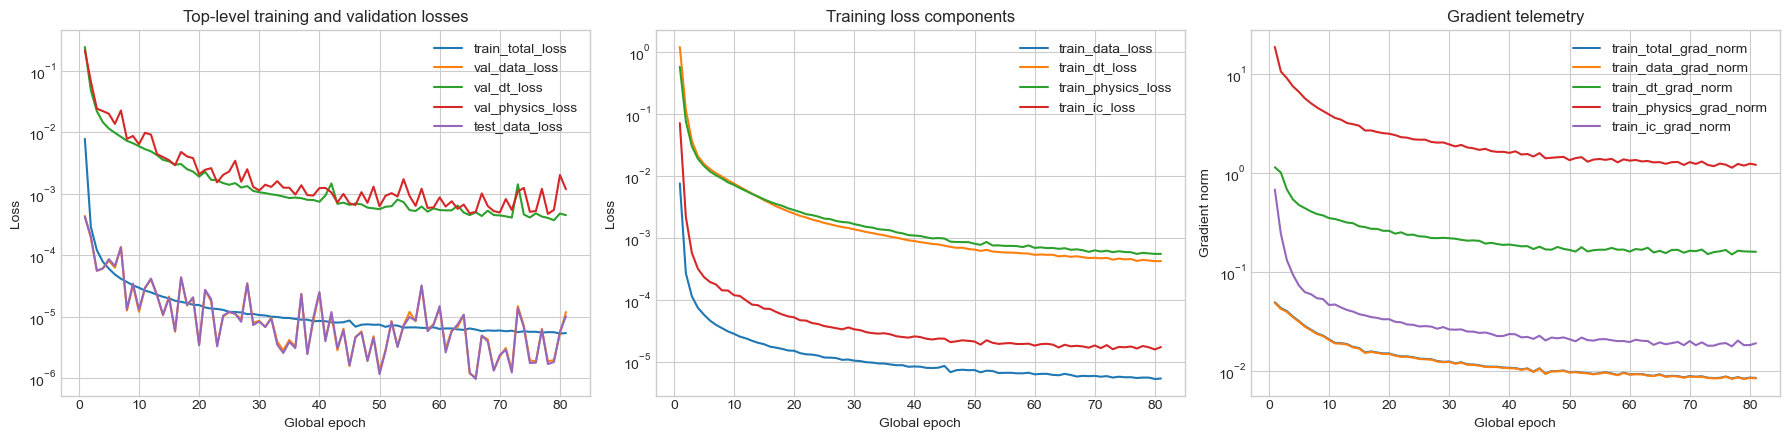

In [4]:
plot_training_curves(metrics)

## Gradient Telemetry

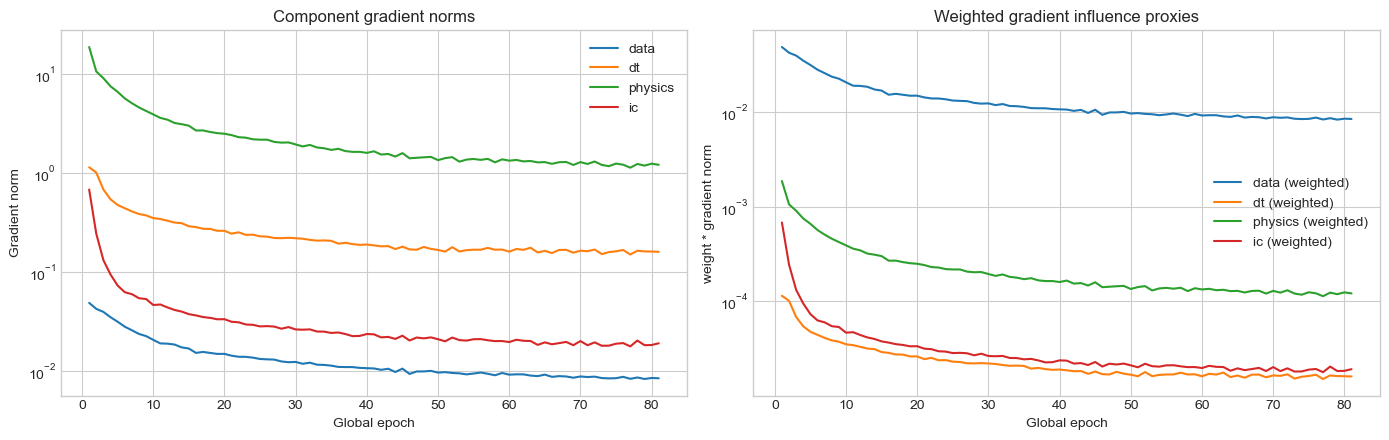

In [5]:
plot_weighted_gradient_influence(metrics, config)

In [6]:
grad_cols = [c for c in metrics.columns if 'grad' in c]
metrics[['global_epoch', *grad_cols]].tail(10)


,global_epoch,train_total_grad_norm,train_data_grad_norm,train_dt_grad_norm,train_physics_grad_norm,train_ic_grad_norm
71,72,0.008915,0.008841,0.169592,1.312448,0.019615
72,73,0.008624,0.008555,0.152589,1.211746,0.018128
73,74,0.008557,0.008490,0.159822,1.177935,0.018172
74,75,0.008600,0.008529,0.162787,1.250405,0.019007
75,76,0.008870,0.008803,0.167856,1.218770,0.019287
76,77,0.008466,0.008404,0.151291,1.136269,0.017858
77,78,0.008742,0.008673,0.164916,1.239641,0.020464
78,79,0.008440,0.008374,0.162427,1.192892,0.018368
79,80,0.008643,0.008573,0.161854,1.247524,0.018437
80,81,0.008582,0.008513,0.160950,1.215951,0.019212


## Numerical Summary of Saved Landscapes

In [7]:
summary_1d = pd.concat([summarize_1d_landscape(name, landscape) for name, landscape in landscapes_1d.items()], ignore_index=True)
summary_2d = pd.concat([summarize_2d_landscape(name, landscape) for name, landscape in landscapes_2d.items()], ignore_index=True)
summary_1d.sort_values(['loss', 'checkpoint'])


,checkpoint,loss,center_alpha,center_value,min_alpha,min_value,max_value,range
10,best,data,0.0,8.978161e-07,0.0,8.978161e-07,0.646097,0.646097
5,epoch_050pct,data,0.0,1.778219e-06,0.0,1.778219e-06,0.606788,0.606787
0,init,data,0.0,6.079013e-01,1.0,5.472584e-01,0.880006,0.332748
15,last,data,0.0,1.136077e-05,0.0,1.136077e-05,0.597225,0.597214
11,best,dt,0.0,2.602120e-04,0.0,2.602120e-04,4.274556,4.274296
6,epoch_050pct,dt,0.0,2.427886e-04,0.0,2.427886e-04,4.040257,4.040014
1,init,dt,0.0,1.631753e+00,-1.0,1.624797e+00,1.633208,0.008411
16,last,dt,0.0,2.699565e-04,0.0,2.699565e-04,3.862202,3.861932
12,best,ic,0.0,5.659364e-06,0.0,5.659364e-06,1.410716,1.410710
7,epoch_050pct,ic,0.0,4.677764e-06,0.0,4.677764e-06,1.410737,1.410732


In [8]:
summary_2d.sort_values(['loss', 'checkpoint'])

,checkpoint,loss,center_alpha,center_beta,center_value,min_alpha,min_beta,min_value,max_value,range
10,best,data,0.0,0.0,8.978161e-07,0.0,0.0,8.978161e-07,1.391917,1.391916
5,epoch_050pct,data,0.0,0.0,1.778219e-06,0.0,0.0,1.778219e-06,1.427576,1.427574
0,init,data,0.0,0.0,6.079013e-01,1.0,-0.8,5.099697e-01,0.925148,0.415178
15,last,data,0.0,0.0,1.136077e-05,0.0,0.0,1.136077e-05,1.423426,1.423415
11,best,dt,0.0,0.0,2.602120e-04,0.0,0.0,2.602120e-04,5.070522,5.070261
6,epoch_050pct,dt,0.0,0.0,2.427886e-04,0.0,0.0,2.427886e-04,4.794023,4.793780
1,init,dt,0.0,0.0,1.631753e+00,-1.0,-0.5,1.615779e+00,1.647763,0.031984
16,last,dt,0.0,0.0,2.699565e-04,0.0,0.0,2.699565e-04,4.610114,4.609844
12,best,ic,0.0,0.0,5.659364e-06,0.0,0.0,5.659364e-06,1.858511,1.858505
7,epoch_050pct,ic,0.0,0.0,4.677764e-06,0.0,0.0,4.677764e-06,1.887918,1.887913


## 1D Loss Slices

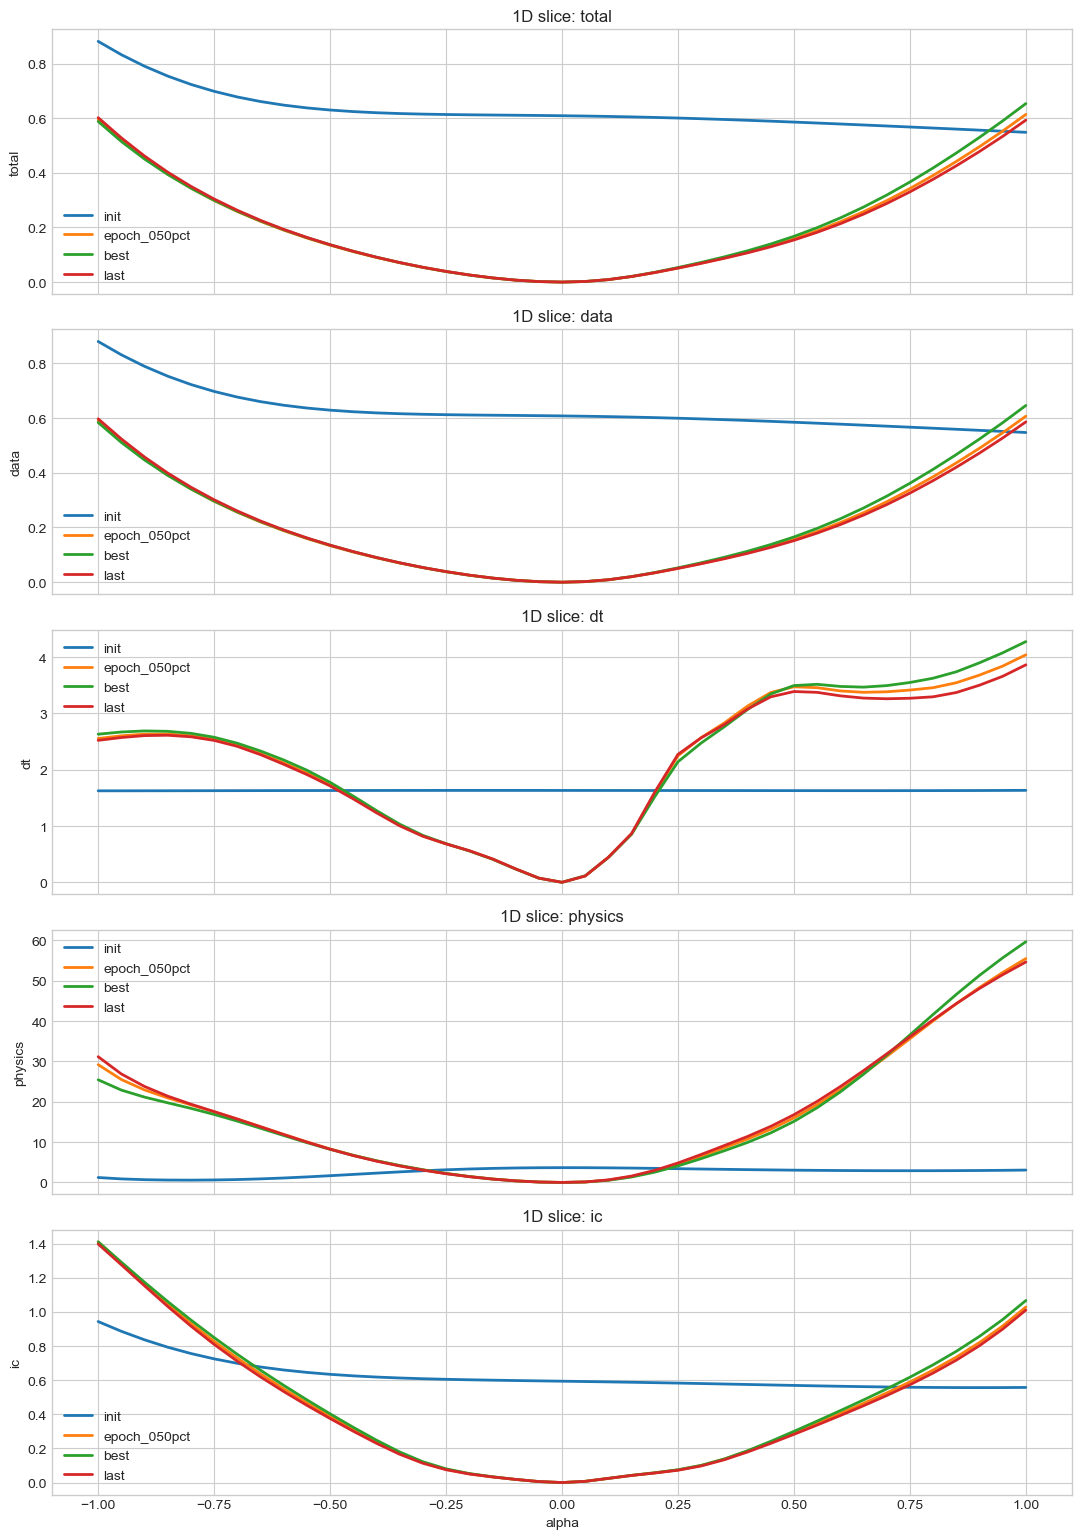

In [9]:
plot_1d_slices(landscapes_1d, log_scale=False)

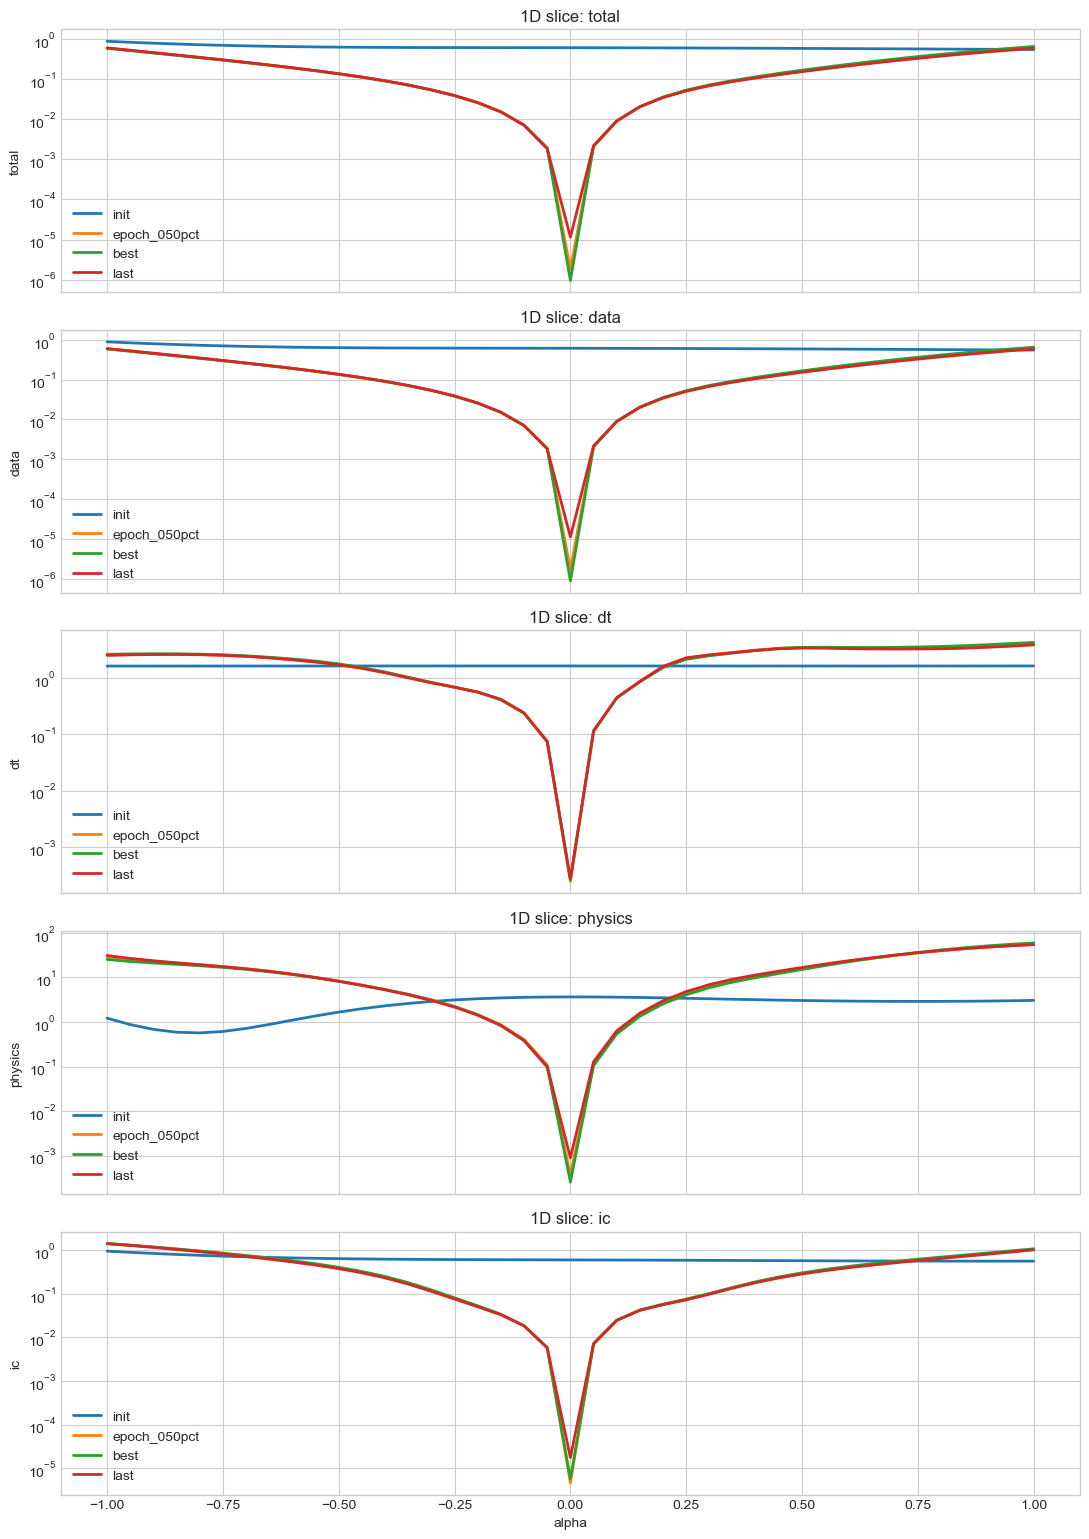

In [10]:
plot_1d_slices(landscapes_1d, log_scale=True)

## 2D Heatmaps

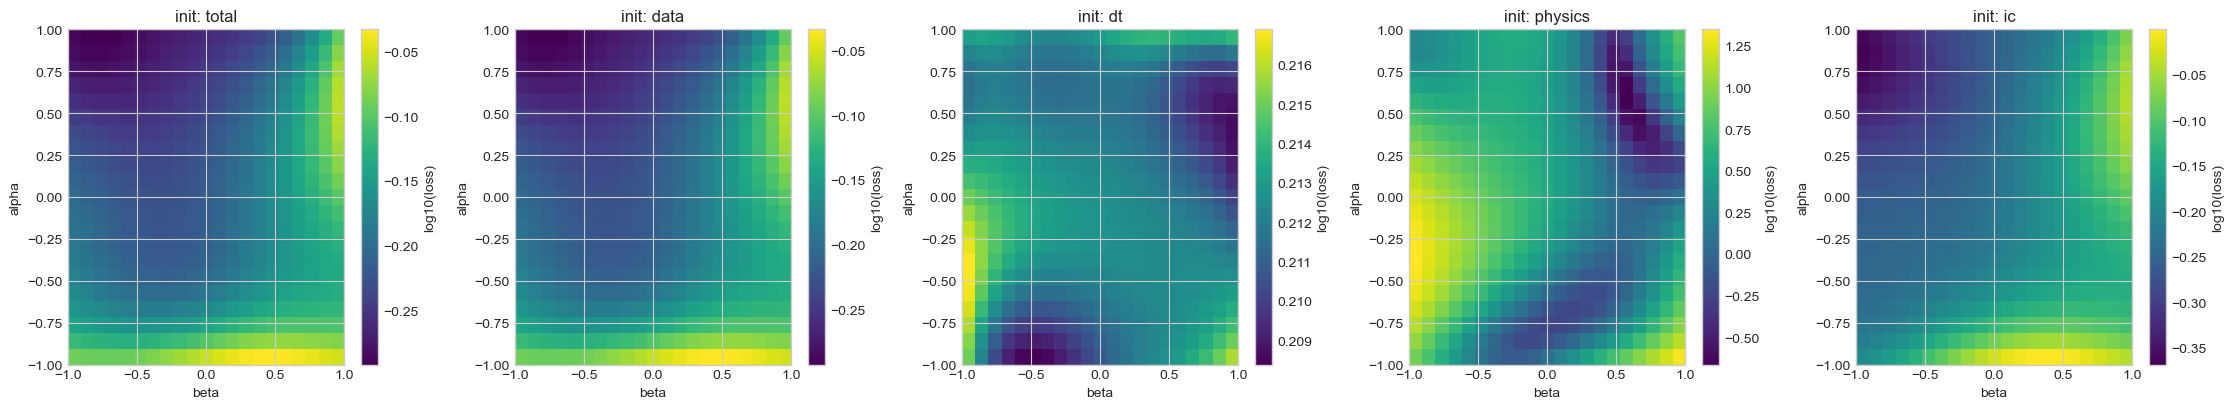

In [11]:
plot_2d_heatmaps(landscapes_2d['init'], 'init', log_scale=True)

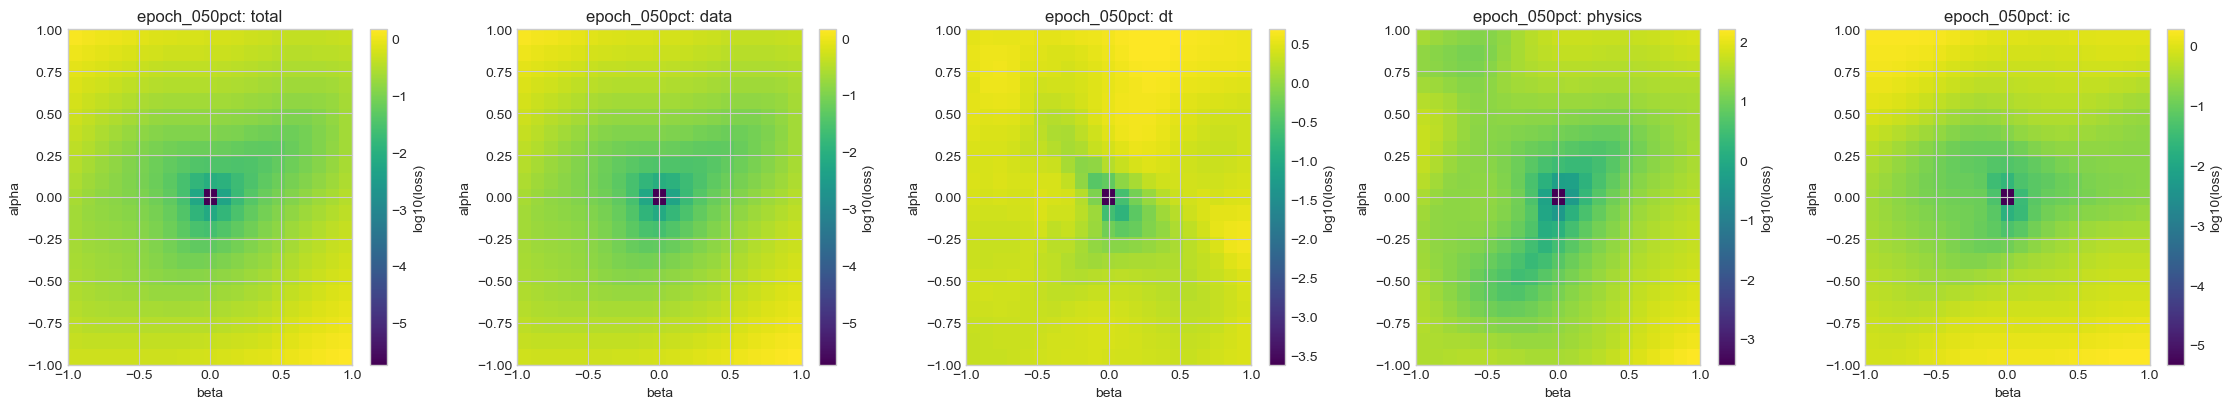

In [12]:
plot_2d_heatmaps(landscapes_2d['epoch_050pct'], 'epoch_050pct', log_scale=True)

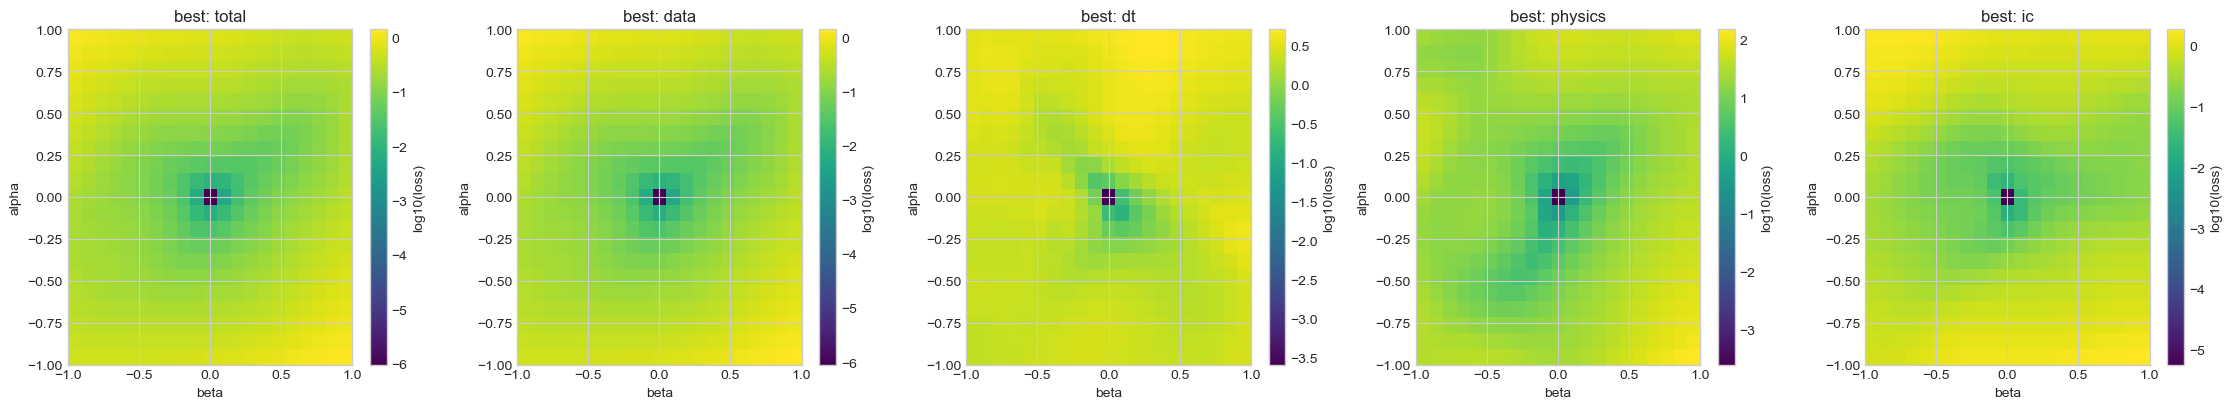

In [13]:
plot_2d_heatmaps(landscapes_2d['best'], 'best', log_scale=True)

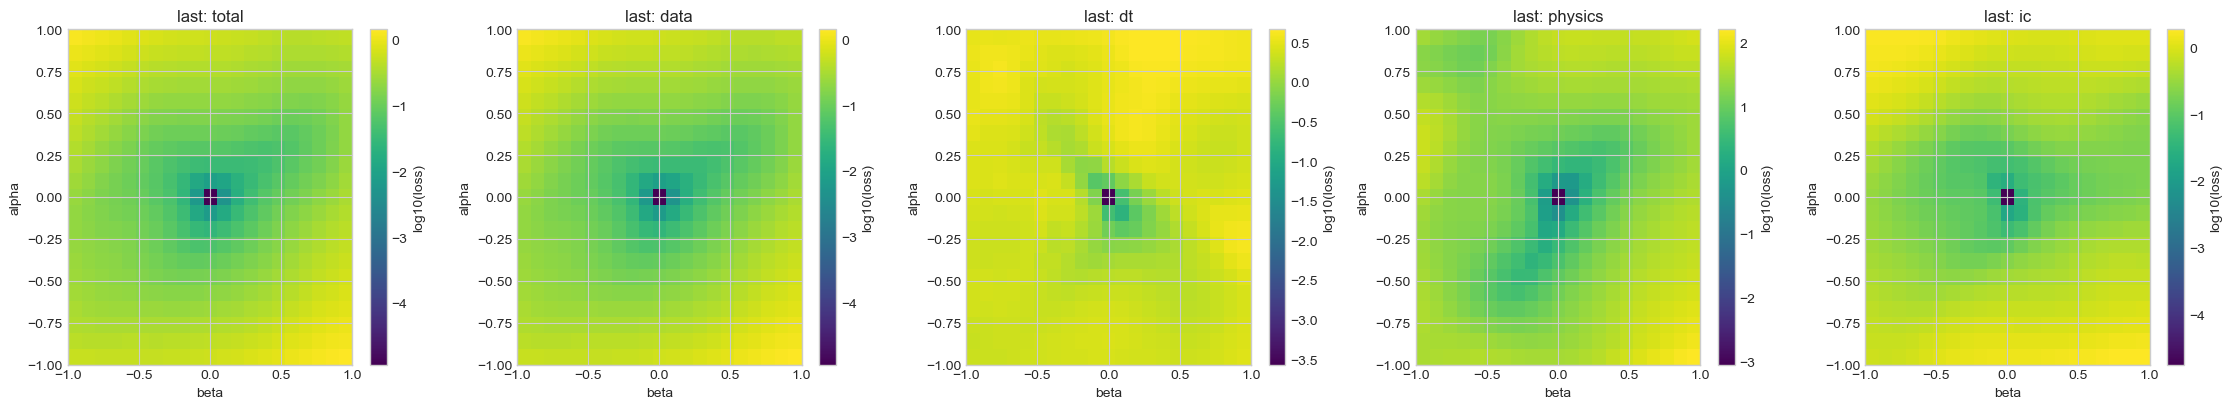

In [14]:
plot_2d_heatmaps(landscapes_2d['last'], 'last', log_scale=True)

## 2D Contour Plots

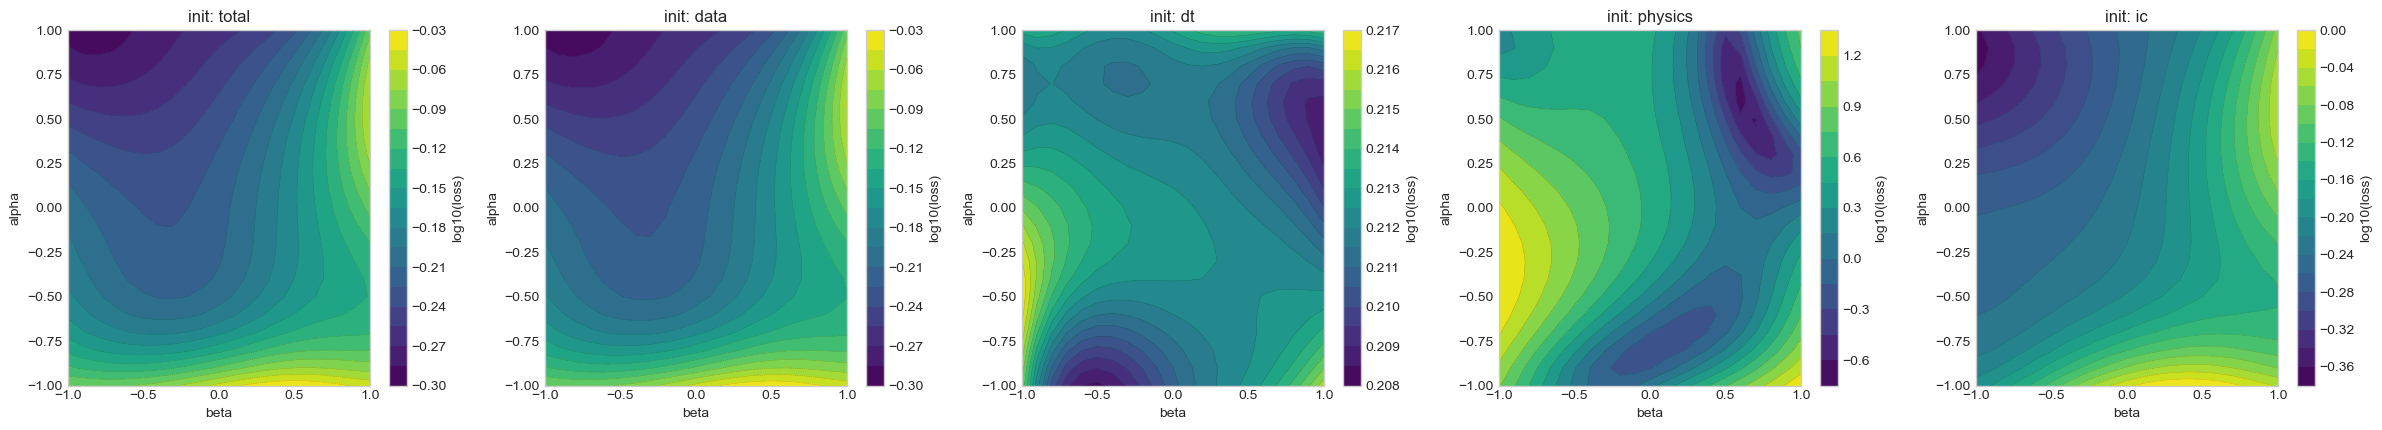

In [15]:
plot_2d_contours(landscapes_2d['init'], 'init', log_scale=True)

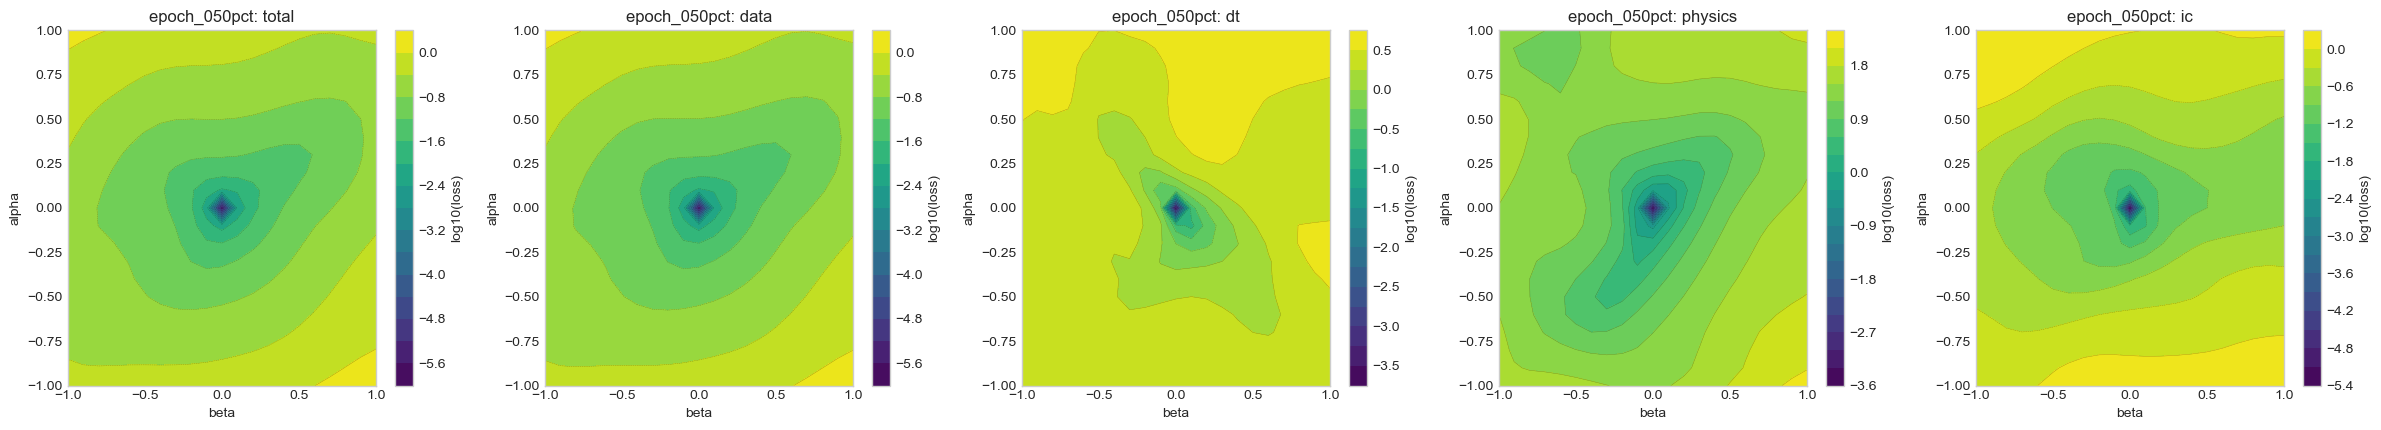

In [16]:
plot_2d_contours(landscapes_2d['epoch_050pct'], 'epoch_050pct', log_scale=True)

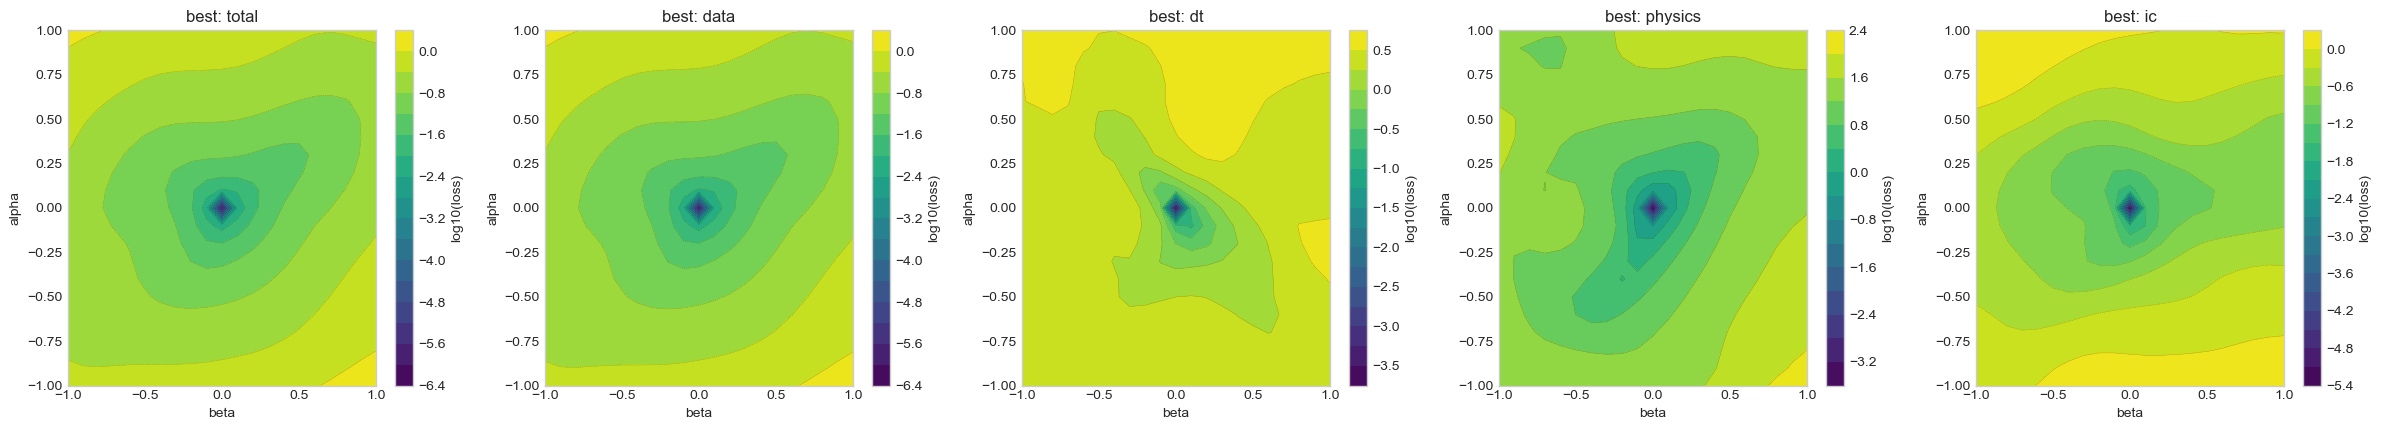

In [17]:
plot_2d_contours(landscapes_2d['best'], 'best', log_scale=True)

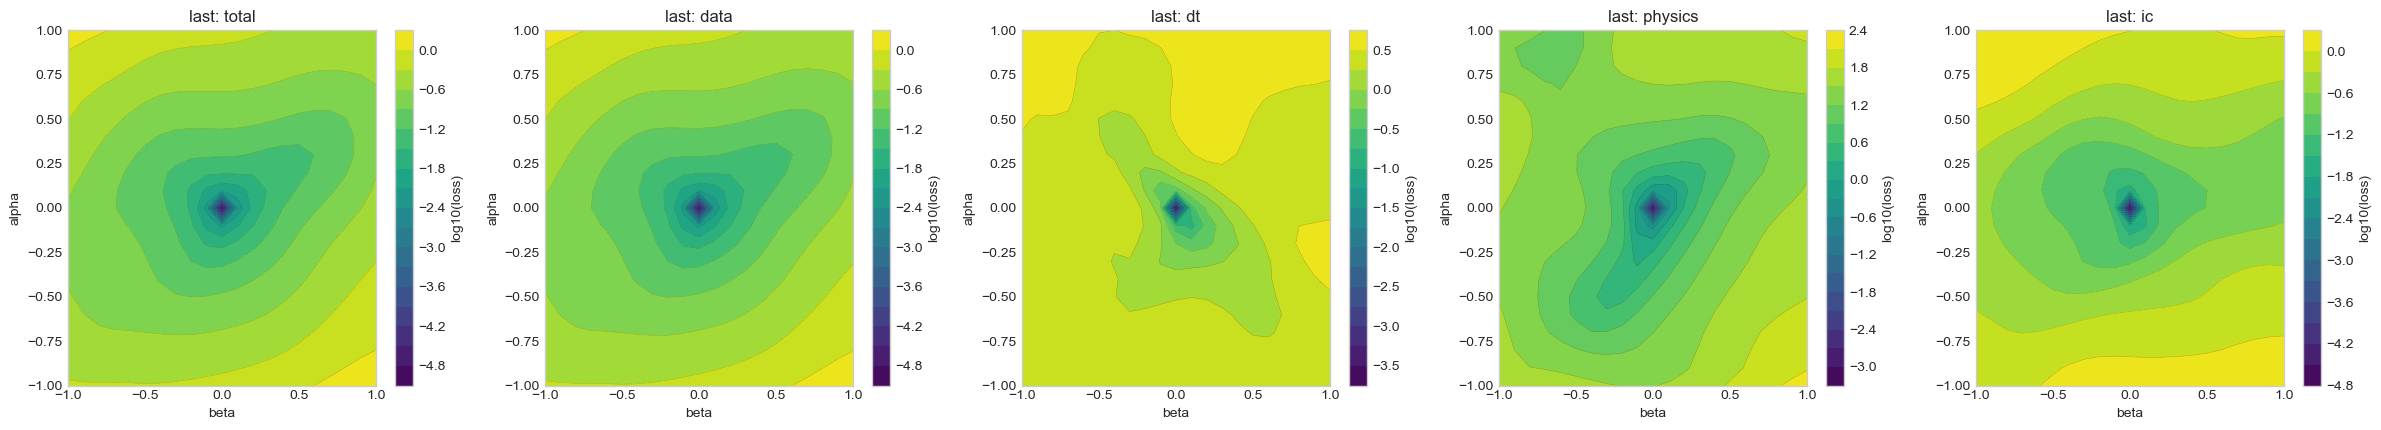

In [18]:
plot_2d_contours(landscapes_2d['last'], 'last', log_scale=True)

## 3D Surface Plots

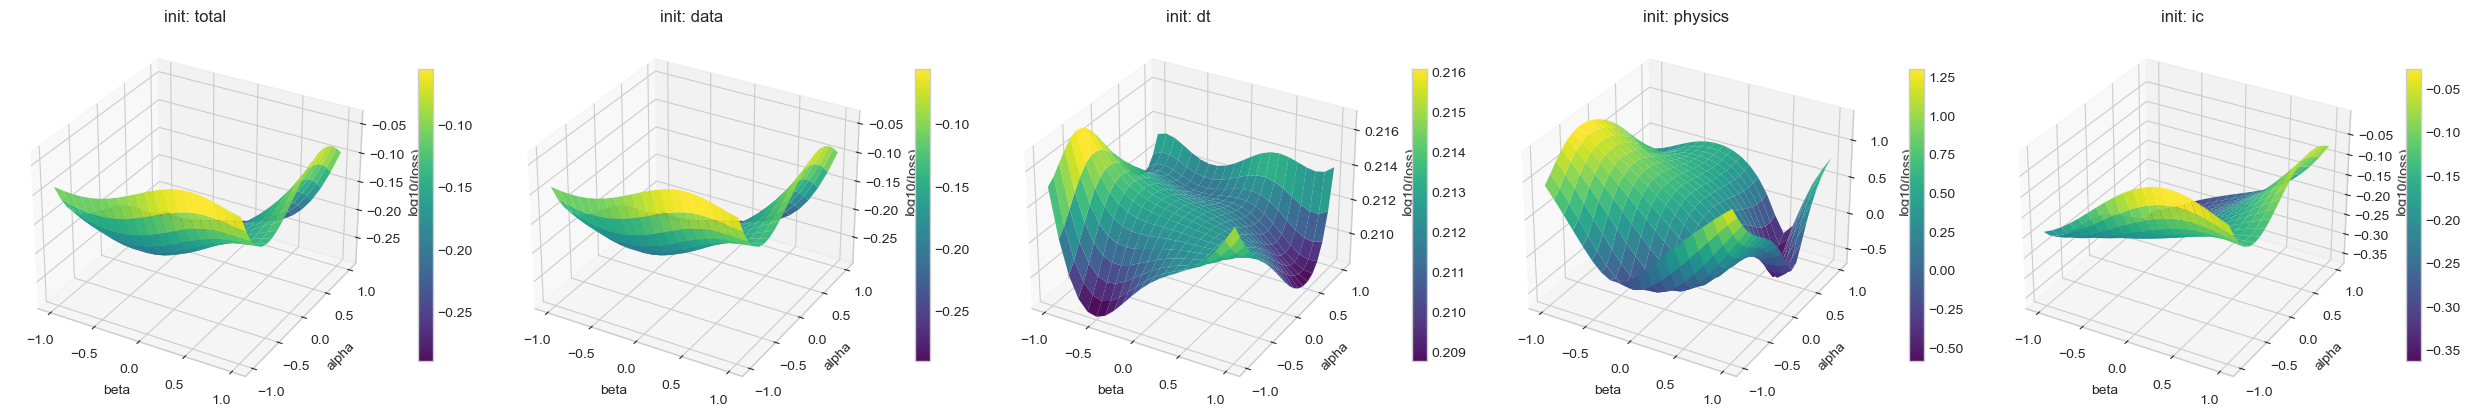

In [19]:
plot_3d_surfaces(landscapes_2d['init'], 'init', log_scale=True)

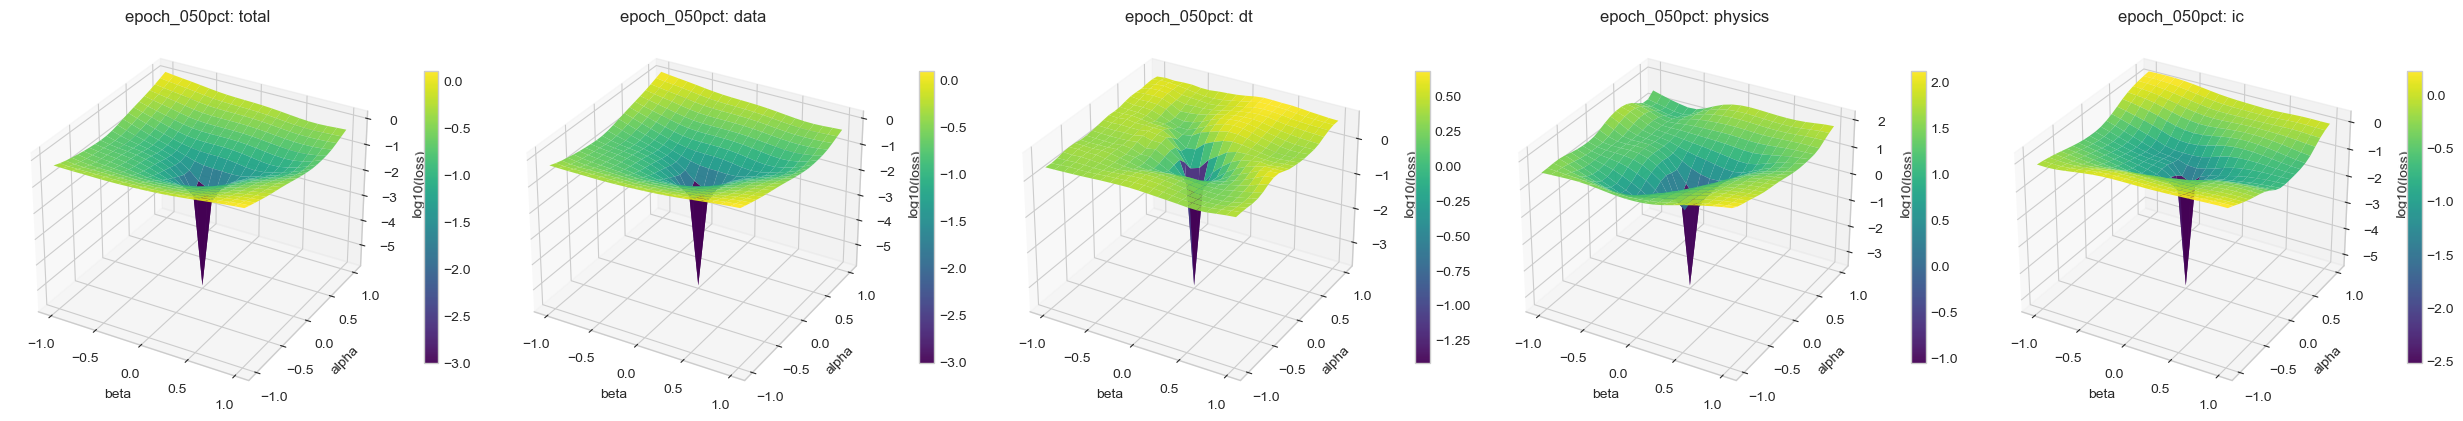

In [20]:
plot_3d_surfaces(landscapes_2d['epoch_050pct'], 'epoch_050pct', log_scale=True)

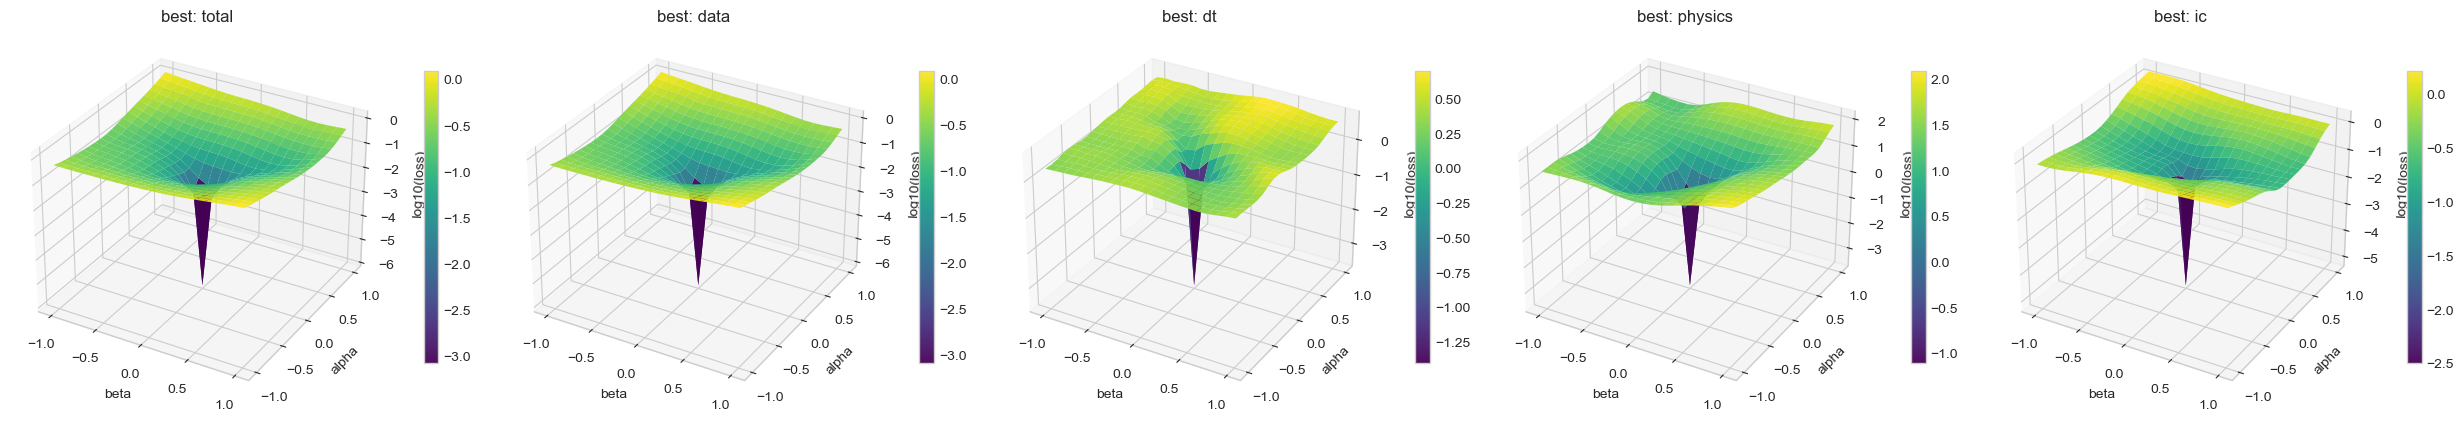

In [21]:
plot_3d_surfaces(landscapes_2d['best'], 'best', log_scale=True)

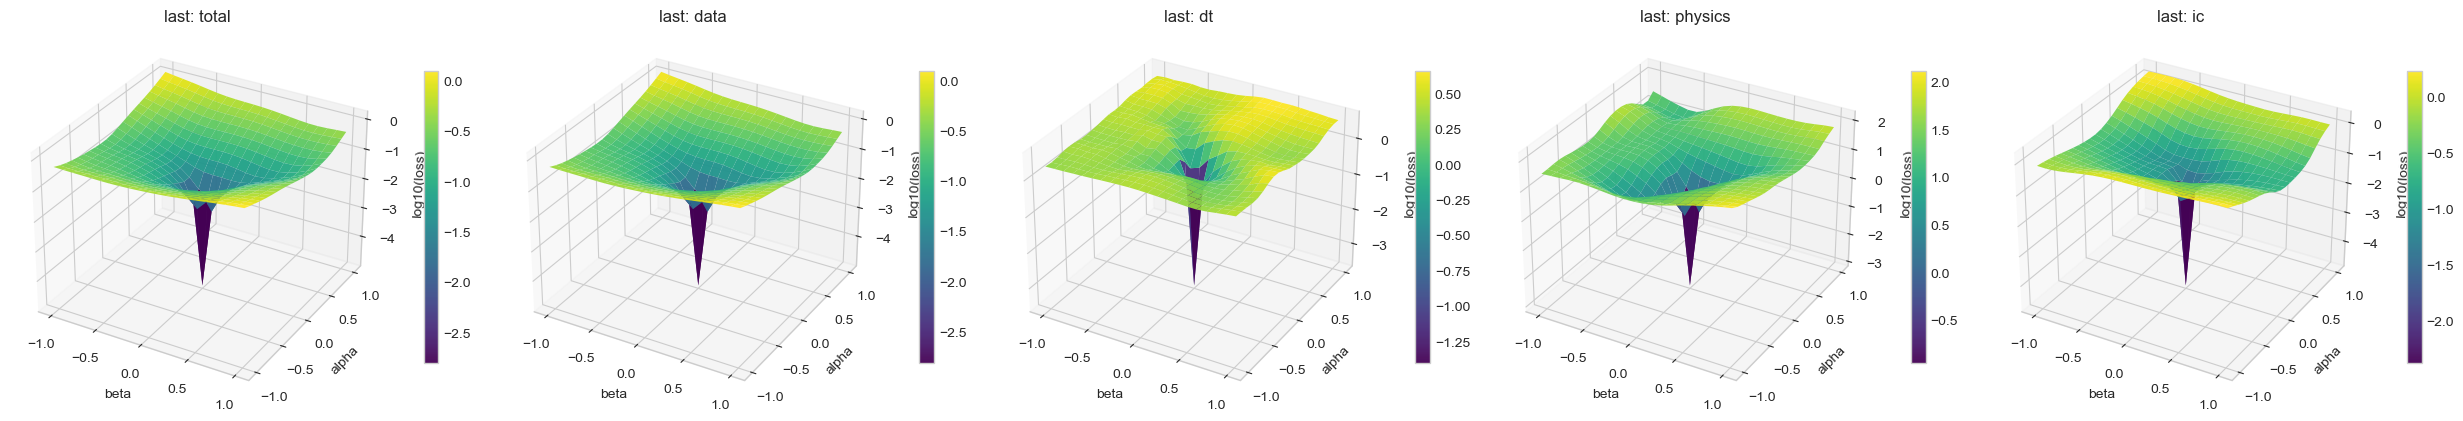

In [22]:
plot_3d_surfaces(landscapes_2d['last'], 'last', log_scale=True)

## Best vs Last Comparison

In [23]:
best_last_1d = summary_1d[(summary_1d['checkpoint'].isin(['best', 'last'])) & (summary_1d['loss'] == 'total')][['checkpoint', 'center_value', 'min_value', 'range']]
best_last_2d = summary_2d[(summary_2d['checkpoint'].isin(['best', 'last'])) & (summary_2d['loss'] == 'total')][['checkpoint', 'center_value', 'min_value', 'range', 'min_alpha', 'min_beta']]
print('1D total-loss comparison:')
display(best_last_1d)
print('')
print('2D total-loss comparison:')
display(best_last_2d)


1D total-loss comparison:


,checkpoint,center_value,min_value,range
14,best,9.548529e-07,9.548529e-07,0.653558
19,last,1.149381e-05,1.149381e-05,0.601980



2D total-loss comparison:


,checkpoint,center_value,min_value,range,min_alpha,min_beta
14,best,9.548529e-07,9.548529e-07,1.409087,0.0,0.0
19,last,1.149381e-05,1.149381e-05,1.441475,0.0,0.0


## Interpretation Notes

In [24]:
print('Interpretation guide:')
print('- Lower center value at alpha=beta=0 for later checkpoints indicates successful optimization progress.')
print('- Comparing best vs last is useful here because the run was interrupted at epoch 81 rather than finishing the planned 150 epochs.')
print('- Gradient telemetry reveals which objective components are actually driving optimization, not just which ones have the largest scalar loss.')
print("- Weighted gradient influence proxies are especially relevant for adaptive weighting because they approximate each term's scaled pull on the parameters.")


Interpretation guide:
- Lower center value at alpha=beta=0 for later checkpoints indicates successful optimization progress.
- Comparing best vs last is useful here because the run was interrupted at epoch 81 rather than finishing the planned 150 epochs.
- Gradient telemetry reveals which objective components are actually driving optimization, not just which ones have the largest scalar loss.
- Weighted gradient influence proxies are especially relevant for adaptive weighting because they approximate each term's scaled pull on the parameters.
